# Day 2 Homework Challenge — AI Product Intelligence System
**Name:** Utkarsh Kumar Rai

This notebook implements all three tasks from the assignment without a web interface:
1. complementary product recommendations,
2. duplicate removal and a unique catalog,
3. reverse product search using a text query.

## Practical approach and assumptions

- **Kaggle/CLIP mode:** finds `styles.csv` and the `images` folder automatically, builds CLIP image embeddings, and uses CLIP text embeddings for retrieval.
- **Demo mode:** uses a small built-in catalog so the complete logic can be checked quickly when the dataset or model is unavailable.
- The provided fashion dataset has no purchase-history table. Therefore Task 1 uses simple complementary-category rules and CLIP ranking. In a real store, the rules should later be learned from “bought together” data.
- The notebook limits the first run to 1,500 products so it can run on a free Kaggle GPU. `MAX_ITEMS` can be increased later.

## Shared pipeline

`Product images → CLIP image embeddings → normalized vector matrix → recommendation / duplicate grouping / text search`

The important final-selection rules are written explicitly inside each task instead of returning an unexplained model output.

In [4]:
from pathlib import Path
import math
import os
import re

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# "auto" tries the Kaggle dataset + CLIP first and falls back to a small demo catalog.
RUN_MODE = "kaggle"          # choices: auto, kaggle, demo
MAX_ITEMS = 1500           # keeps the notebook practical on a free Kaggle GPU
BATCH_SIZE = 32
TOP_K = 5
DUPLICATE_THRESHOLD = 0.95
MIN_SEARCH_SCORE = 0.15
MODEL_NAME = "openai/clip-vit-base-patch32"
WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./day2_outputs")
WORK_DIR.mkdir(parents=True, exist_ok=True)


def normalize_text(value):
    return re.sub(r"[^a-z0-9]+", " ", str(value).lower()).strip()


def l2_normalize(values):
    values = np.asarray(values, dtype=np.float32)
    denominator = np.linalg.norm(values, axis=1, keepdims=True)
    return values / np.clip(denominator, 1e-12, None)

In [5]:
DEMO_PRODUCTS = [
    (1001, "Blue Casual Shirt A", "Men", "Apparel", "Topwear", "Shirts", "Blue", "Summer", "Casual", "blue-shirt"),
    (1002, "Blue Casual Shirt B", "Men", "Apparel", "Topwear", "Shirts", "Blue", "Summer", "Casual", "blue-shirt"),
    (1003, "Blue Casual Shirt C", "Men", "Apparel", "Topwear", "Shirts", "Blue", "Summer", "Casual", "blue-shirt"),
    (1004, "White Formal Shirt", "Men", "Apparel", "Topwear", "Shirts", "White", "Fall", "Formal", "white-shirt"),
    (2001, "Black Jeans", "Men", "Apparel", "Bottomwear", "Jeans", "Black", "Fall", "Casual", "black-jeans"),
    (2002, "Blue Jeans", "Men", "Apparel", "Bottomwear", "Jeans", "Blue", "Fall", "Casual", "blue-jeans"),
    (3001, "Black Running Shoe A", "Men", "Footwear", "Shoes", "Sports Shoes", "Black", "Summer", "Sports", "black-running-shoe"),
    (3002, "Black Running Shoe B", "Men", "Footwear", "Shoes", "Sports Shoes", "Black", "Summer", "Sports", "black-running-shoe"),
    (3003, "Red Running Shoe", "Men", "Footwear", "Shoes", "Sports Shoes", "Red", "Summer", "Sports", "red-running-shoe"),
    (4001, "Black Sports Socks", "Unisex", "Accessories", "Socks", "Socks", "Black", "Summer", "Sports", "sports-socks"),
    (5001, "Black Fitness Watch", "Unisex", "Accessories", "Watches", "Watches", "Black", "All", "Sports", "fitness-watch"),
    (6001, "Blue Water Bottle", "Unisex", "Accessories", "Bottles", "Water Bottle", "Blue", "All", "Sports", "water-bottle"),
    (7001, "Brown Casual Shoes", "Men", "Footwear", "Shoes", "Casual Shoes", "Brown", "Fall", "Casual", "brown-casual-shoes"),
    (8001, "Black Sports Backpack", "Unisex", "Accessories", "Bags", "Backpacks", "Black", "All", "Sports", "sports-backpack"),
]

FEATURE_TOKENS = [
    "blue", "black", "red", "white", "brown",
    "shirts", "jeans", "sports shoes", "socks", "watches",
    "water bottle", "casual shoes", "backpacks",
    "casual", "formal", "sports"
]


def canonical_article_type(value):
    value = normalize_text(value)
    aliases = [
        ("running shoe", "sports shoes"), ("sport shoe", "sports shoes"),
        ("sports shoe", "sports shoes"), ("shirt", "shirts"),
        ("watch", "watches"), ("sock", "socks"),
        ("water bottle", "water bottle"), ("bottle", "water bottle"),
        ("casual shoe", "casual shoes"), ("backpack", "backpacks"),
        ("jean", "jeans")
    ]
    for phrase, canonical in aliases:
        if phrase in value:
            return canonical
    return value


def make_demo_image(row, image_path):
    colors = {"blue": "#4f7fc4", "black": "#282c34", "red": "#ca4b4b", "white": "#eeeeee", "brown": "#9a6a45"}
    canvas = Image.new("RGB", (260, 260), "white")
    draw = ImageDraw.Draw(canvas)
    color = colors.get(normalize_text(row.baseColour), "#7b8794")
    item = canonical_article_type(row.articleType)
    if item == "shirts":
        draw.polygon([(80, 60), (110, 40), (150, 40), (180, 60), (165, 105), (165, 210), (95, 210), (95, 105)], fill=color, outline="#333333")
    elif "shoes" in item:
        draw.polygon([(45, 155), (135, 125), (185, 160), (220, 175), (210, 205), (60, 205)], fill=color, outline="#333333")
    elif item == "jeans":
        draw.polygon([(90, 45), (170, 45), (162, 215), (132, 215), (125, 105), (118, 215), (88, 215)], fill=color, outline="#333333")
    elif item == "watches":
        draw.rectangle((116, 35, 144, 225), fill=color); draw.ellipse((85, 90, 175, 180), fill="#d9dee5", outline="#333333", width=3)
    elif item == "water bottle":
        draw.rectangle((100, 60, 160, 220), fill=color, outline="#333333"); draw.rectangle((115, 35, 145, 65), fill="#555555")
    elif item == "socks":
        draw.polygon([(85, 45), (130, 45), (130, 155), (180, 180), (160, 215), (90, 180)], fill=color, outline="#333333")
    else:
        draw.rounded_rectangle((65, 55, 195, 215), radius=18, fill=color, outline="#333333")
    draw.text((12, 232), str(row.productDisplayName)[:36], fill="#111111")
    canvas.save(image_path)


def build_demo_catalog():
    columns = ["id", "productDisplayName", "gender", "masterCategory", "subCategory", "articleType", "baseColour", "season", "usage", "true_group"]
    catalog = pd.DataFrame(DEMO_PRODUCTS, columns=columns)
    demo_dir = WORK_DIR / "demo_images"
    demo_dir.mkdir(parents=True, exist_ok=True)
    image_paths = []
    for row in catalog.itertuples(index=False):
        image_path = demo_dir / f"{row.id}.png"
        make_demo_image(row, image_path)
        image_paths.append(str(image_path))
    catalog["image_path"] = image_paths
    catalog["image_width"] = 260
    catalog["image_height"] = 260
    catalog["canonical_type"] = catalog["articleType"].map(canonical_article_type)
    return catalog


def demo_text_embeddings(texts):
    vectors = []
    for text in texts:
        normalized = normalize_text(text)
        canonical = canonical_article_type(normalized)
        expanded = normalized + " " + canonical
        vector = [1.0 if token in expanded else 0.0 for token in FEATURE_TOKENS]
        if not any(vector):
            vector[-3:] = [1.0, 0.0, 0.0]
        vectors.append(vector)
    return l2_normalize(vectors)


def build_demo_embeddings(catalog):
    descriptions = catalog.apply(
        lambda row: f"{row.baseColour} {row.articleType} for {row.usage}", axis=1
    ).tolist()
    return demo_text_embeddings(descriptions)

In [6]:
def find_kaggle_dataset():
    input_root = Path("/kaggle/input")
    if not input_root.exists():
        raise FileNotFoundError("/kaggle/input is not available")
    for styles_path in input_root.rglob("styles.csv"):
        candidates = [styles_path.parent / "images", styles_path.parent.parent / "images"]
        for images_dir in candidates:
            if images_dir.is_dir():
                return styles_path, images_dir
    raise FileNotFoundError("Could not find styles.csv with an images folder under /kaggle/input")


def load_kaggle_catalog(max_items=MAX_ITEMS):
    styles_path, images_dir = find_kaggle_dataset()
    catalog = pd.read_csv(styles_path, on_bad_lines="skip")
    required = ["id", "gender", "masterCategory", "subCategory", "articleType", "baseColour", "season", "usage", "productDisplayName"]
    missing = [column for column in required if column not in catalog.columns]
    if missing:
        raise ValueError(f"Dataset is missing columns: {missing}")
    catalog = catalog.dropna(subset=["id", "articleType", "productDisplayName"]).copy()
    catalog["id"] = catalog["id"].astype(int)
    catalog["image_path"] = catalog["id"].map(lambda value: str(images_dir / f"{value}.jpg"))
    catalog = catalog[catalog["image_path"].map(lambda value: Path(value).exists())].copy()

    # Balanced sampling avoids returning only the largest product categories.
    per_type = max(2, math.ceil(max_items / max(1, catalog["articleType"].nunique())))
    sampled = []
    for _, group in catalog.groupby("articleType"):
        sampled.append(group.sample(min(len(group), per_type), random_state=42))
    catalog = pd.concat(sampled, ignore_index=True).head(max_items).copy()

    dimensions = []
    valid_rows = []
    for index, path in enumerate(catalog["image_path"]):
        try:
            with Image.open(path) as image:
                dimensions.append(image.size)
            valid_rows.append(index)
        except Exception:
            pass
    catalog = catalog.iloc[valid_rows].reset_index(drop=True)
    catalog["image_width"] = [dimensions[i][0] for i in range(len(dimensions))]
    catalog["image_height"] = [dimensions[i][1] for i in range(len(dimensions))]
    catalog["canonical_type"] = catalog["articleType"].map(canonical_article_type)
    return catalog


def load_clip_backend():
    import torch
    from transformers import CLIPModel, CLIPProcessor
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = CLIPModel.from_pretrained(MODEL_NAME).to(device).eval()
    processor = CLIPProcessor.from_pretrained(MODEL_NAME)
    return model, processor, device, torch


def clip_image_embeddings(catalog, model, processor, device, torch):
    all_features = []

    for start in range(0, len(catalog), BATCH_SIZE):
        paths = catalog["image_path"].iloc[start:start + BATCH_SIZE]
        images = [Image.open(path).convert("RGB") for path in paths]
        inputs = processor(images=images, return_tensors="pt").to(device)

        with torch.no_grad():
            output = model.vision_model(
                pixel_values=inputs["pixel_values"]
            )
            features = model.visual_projection(output.pooler_output)

        all_features.append(features.detach().cpu().numpy())

        for image in images:
            image.close()

    return l2_normalize(np.vstack(all_features))

def make_clip_text_encoder(model, processor, device, torch):
    def encode(texts):
        inputs = processor(
            text=list(texts),
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(device)

        with torch.no_grad():
            output = model.text_model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
            )
            features = model.text_projection(output.pooler_output)

        return l2_normalize(features.detach().cpu().numpy())

    return encode


def prepare_catalog_and_embeddings():
    if RUN_MODE in {"auto", "kaggle"}:
        try:
            catalog = load_kaggle_catalog()
            model, processor, device, torch = load_clip_backend()
            image_embeddings = clip_image_embeddings(catalog, model, processor, device, torch)
            text_encoder = make_clip_text_encoder(model, processor, device, torch)
            return catalog, image_embeddings, text_encoder, "kaggle-clip"
        except Exception as error:
            if RUN_MODE == "kaggle":
                raise
            print(f"Kaggle/CLIP mode unavailable ({error}). Using the built-in demo catalog.")

    catalog = build_demo_catalog()
    image_embeddings = build_demo_embeddings(catalog)
    return catalog, image_embeddings, demo_text_embeddings, "demo"


catalog, image_embeddings, encode_texts, BACKEND = prepare_catalog_and_embeddings()
print(f"Backend: {BACKEND}")
print(f"Catalog items: {len(catalog)} | embedding shape: {image_embeddings.shape}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Backend: kaggle-clip
Catalog items: 1331 | embedding shape: (1331, 512)


In [7]:
def show_products(rows, title, score_column=None, columns=4):
    if len(rows) == 0:
        print("No products to display.")
        return
    columns = min(columns, len(rows))
    rows_count = math.ceil(len(rows) / columns)
    figure, axes = plt.subplots(rows_count, columns, figsize=(4 * columns, 4 * rows_count))
    axes = np.atleast_1d(axes).reshape(-1)
    for axis in axes:
        axis.axis("off")
    for axis, (_, row) in zip(axes, rows.iterrows()):
        with Image.open(row.image_path) as image:
            axis.imshow(image.convert("RGB"))
        label = row.productDisplayName
        if score_column and score_column in row:
            label += f"\nscore={row[score_column]:.3f}"
        axis.set_title(label, fontsize=9)
        axis.axis("off")
    figure.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

## Task 1 — Smart Product Recommendation Engine

**Logic:** First map the input product to categories that normally complement it. For each target category, filter valid products, calculate a score (`70% text-to-image relevance + 30% visual style similarity`), and keep the highest-scoring item. Keeping one item per category prevents three nearly identical recommendations.

Input: Lino Perros Men Formal Purple Accessory Gift Set
                productDisplayName canonical_type  final_score
             Revv Men Steel Bangle         bangle     0.706688
Mark Taylor Men Grey Striped Shirt         shirts     0.705502
        Red Rose Purple Nightdress     baby dolls     0.695798

Selection rule: filter by complementary category, rank with CLIP, then keep the best item per category.


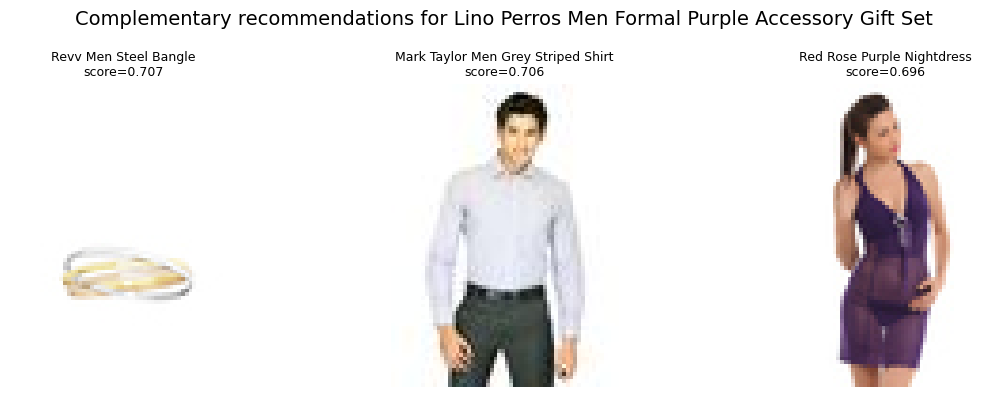

In [8]:
COMPLEMENT_RULES = {
    "sports shoes": ["socks", "watches", "water bottle", "backpacks"],
    "casual shoes": ["jeans", "shirts", "watches"],
    "shirts": ["jeans", "casual shoes", "watches"],
    "jeans": ["shirts", "casual shoes", "watches"],
    "tshirts": ["jeans", "sports shoes", "watches"],
    "watches": ["shirts", "casual shoes", "backpacks"],
}


def recommend_complements(product_id, top_k=3):
    matches = catalog.index[catalog["id"] == int(product_id)].tolist()
    if not matches:
        raise KeyError(f"Product id {product_id} was not found")
    query_index = matches[0]
    query = catalog.loc[query_index]
    query_type = canonical_article_type(query.articleType)
    targets = COMPLEMENT_RULES.get(query_type, [])
    if not targets:
        targets = [value for value in catalog["canonical_type"].value_counts().index if value != query_type][:3]

    selected = []
    for target in targets:
        candidates = catalog[(catalog["canonical_type"] == target) & (catalog["id"] != query.id)].copy()
        if query.gender != "Unisex":
            gender_matches = candidates[candidates["gender"].isin([query.gender, "Unisex"])]
            if len(gender_matches):
                candidates = gender_matches
        if candidates.empty:
            continue

        candidate_indices = candidates.index.to_numpy()
        prompt = f"{target} that goes well with {query.baseColour} {query.articleType} for {query.usage}"
        prompt_embedding = encode_texts([prompt])[0]
        text_score = image_embeddings[candidate_indices] @ prompt_embedding
        style_score = image_embeddings[candidate_indices] @ image_embeddings[query_index]
        candidates["final_score"] = 0.70 * ((text_score + 1) / 2) + 0.30 * ((style_score + 1) / 2)

        # Final choice for this complementary category: the highest scoring candidate.
        selected.append(candidates.sort_values("final_score", ascending=False).iloc[0])
        if len(selected) == top_k:
            break

    if not selected:
        return pd.DataFrame(columns=list(catalog.columns) + ["final_score"])
    recommendations = pd.DataFrame(selected).sort_values("final_score", ascending=False).reset_index(drop=True)
    return recommendations


# Example requested in the homework.
query_product_id = 3001 if BACKEND == "demo" else int(catalog.iloc[0].id)
recommendations = recommend_complements(query_product_id, top_k=3)
query_name = catalog.loc[catalog["id"] == query_product_id, "productDisplayName"].iloc[0]
print("Input:", query_name)
print(recommendations[["productDisplayName", "canonical_type", "final_score"]].to_string(index=False))
print("\nSelection rule: filter by complementary category, rank with CLIP, then keep the best item per category.")
show_products(recommendations, f"Complementary recommendations for {query_name}", "final_score", columns=3)

## Task 2 — Unique Product Catalog Creation

**Logic:** Calculate image-to-image cosine similarity. Two products become a duplicate pair only when the similarity is above the threshold **and** their product category matches. Connected pairs form one group. The final representative is the clearest/largest image; if image quality is equal, the lowest product ID is kept so the result is repeatable.

In [9]:
class UnionFind:
    def __init__(self, size):
        self.parent = list(range(size))

    def find(self, item):
        while self.parent[item] != item:
            self.parent[item] = self.parent[self.parent[item]]
            item = self.parent[item]
        return item

    def union(self, left, right):
        left_root, right_root = self.find(left), self.find(right)
        if left_root != right_root:
            self.parent[right_root] = left_root


def create_unique_catalog(threshold=DUPLICATE_THRESHOLD):
    similarities = image_embeddings @ image_embeddings.T
    pairs = np.argwhere(np.triu(similarities, k=1) >= threshold)
    groups = UnionFind(len(catalog))
    accepted_pairs = []
    for left, right in pairs:
        # Category check avoids grouping a black shoe with a black watch.
        if catalog.loc[left, "canonical_type"] != catalog.loc[right, "canonical_type"]:
            continue
        groups.union(int(left), int(right))
        accepted_pairs.append((int(left), int(right), float(similarities[left, right])))

    members = {}
    for index in range(len(catalog)):
        members.setdefault(groups.find(index), []).append(index)

    representatives = []
    group_rows = []
    for group_number, indices in enumerate(members.values(), start=1):
        group = catalog.loc[indices].copy()
        group["quality"] = group["image_width"] * group["image_height"]
        representative_index = group.sort_values(["quality", "id"], ascending=[False, True]).index[0]
        representatives.append(representative_index)
        if len(indices) > 1:
            group_rows.append({
                "group": group_number,
                "member_ids": group["id"].astype(str).str.cat(sep=", "),
                "member_names": group["productDisplayName"].str.cat(sep=" | "),
                "kept_id": int(catalog.loc[representative_index, "id"]),
                "size": len(indices),
            })

    unique_catalog = catalog.loc[sorted(representatives)].copy().reset_index(drop=True)
    duplicate_groups = pd.DataFrame(group_rows)
    return unique_catalog, duplicate_groups, accepted_pairs


unique_catalog, duplicate_groups, duplicate_pairs = create_unique_catalog()
print(f"Original catalog: {len(catalog)} products")
print(f"Duplicate groups: {len(duplicate_groups)}")
print(f"Final unique catalog: {len(unique_catalog)} products")
if len(duplicate_groups):
    print(duplicate_groups[["group", "member_ids", "kept_id", "size"]].to_string(index=False))

# In demo mode the true groups are known, so pairwise precision/recall can be checked.
if BACKEND == "demo":
    predicted = {tuple(sorted((left, right))) for left, right, _ in duplicate_pairs}
    truth = set()
    for _, group in catalog.groupby("true_group"):
        indices = list(group.index)
        if len(indices) > 1:
            truth.update((indices[i], indices[j]) for i in range(len(indices)) for j in range(i + 1, len(indices)))
    true_positive = len(predicted & truth)
    precision = true_positive / max(1, len(predicted))
    recall = true_positive / max(1, len(truth))
    f1 = 2 * precision * recall / max(1e-12, precision + recall)
    print(f"Demo duplicate metrics: precision={precision:.2f}, recall={recall:.2f}, F1={f1:.2f}")

Original catalog: 1331 products
Duplicate groups: 109
Final unique catalog: 1132 products
 group                                                        member_ids  kept_id  size
     1                                               25060, 25048, 25045    25045     3
     4                                                      17371, 17360    17360     2
    23                                                       4583, 35205     4583     2
    30                                                      48753, 48752    48752     2
    32                                                      43724, 43753    43724     2
    69                                                      19892, 35065    19892     2
    71                                                      27838, 19510    19510     2
    77                                               31732, 31729, 31743    31729     3
    87                                                      37574, 37549    37549     2
    88                        

## Task 3 — Reverse Product Search

The notebook uses a function rather than a UI: `reverse_search("blue casual shirt", top_k=5)`. CLIP converts the text into the same vector space as the images. Products are sorted by cosine similarity, low-score results are rejected, and the top products are displayed.

Query: blue casual shirt
                     productDisplayName articleType baseColour  search_score
       French Connection Women Blue Top        Tops       Blue      0.268909
 Forever New Women Vintage Blue Jackets     Jackets       Blue      0.267686
         Pepe Jeans Men Dark Blue Jeans       Jeans       Blue      0.262348
Basics Men White Slim Fit Checked Shirt      Shirts      White      0.258809
            Lee Men Check Yellow Shirts      Shirts     Yellow      0.257095


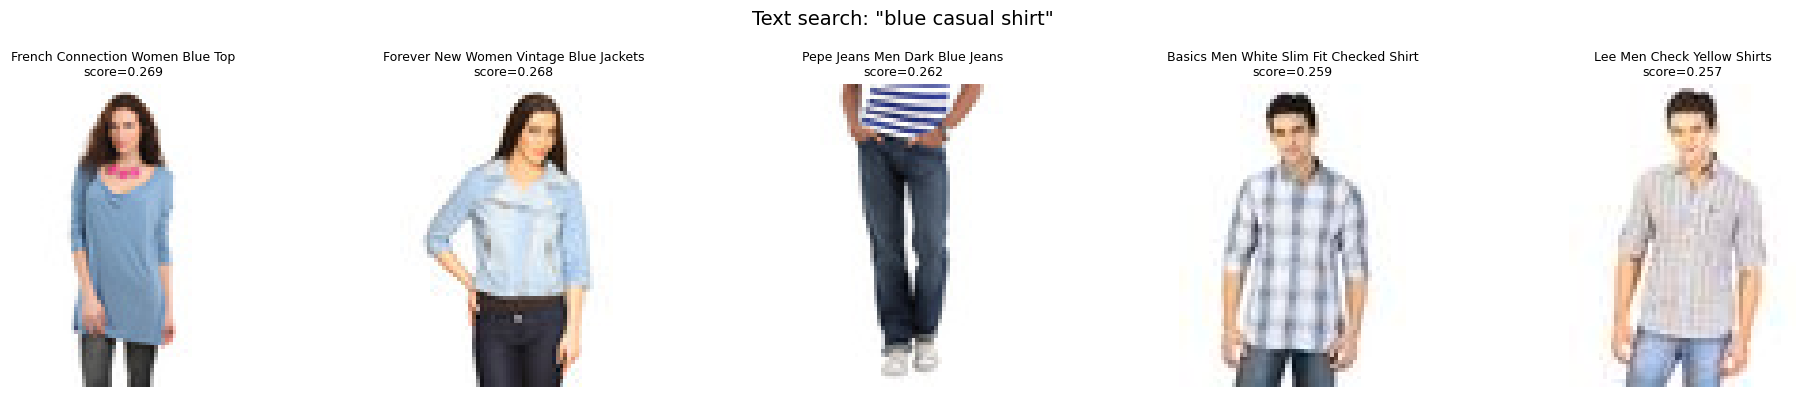

In [10]:
def reverse_search(query, top_k=5, minimum_score=MIN_SEARCH_SCORE):
    query_embedding = encode_texts([query])[0]
    scores = image_embeddings @ query_embedding
    ranking = np.argsort(-scores)[:top_k]
    results = catalog.loc[ranking].copy()
    results["search_score"] = scores[ranking]
    results = results[results["search_score"] >= minimum_score].reset_index(drop=True)
    return results


def evaluate_search_at_k(test_queries, k_values=(3, 5, 10)):
    rows = []
    for query, relevant_ids in test_queries:
        ranked = reverse_search(query, top_k=max(k_values), minimum_score=-1)
        ranked_ids = ranked["id"].tolist()
        row = {"query": query}
        for k in k_values:
            found = len(set(ranked_ids[:k]) & set(relevant_ids))
            row[f"Recall@{k}"] = found / max(1, len(relevant_ids))
        reciprocal_rank = 0.0
        for rank, product_id in enumerate(ranked_ids, start=1):
            if product_id in relevant_ids:
                reciprocal_rank = 1.0 / rank
                break
        row["MRR"] = reciprocal_rank
        rows.append(row)
    return pd.DataFrame(rows)


query = "blue casual shirt"
search_results = reverse_search(query, top_k=5)
print("Query:", query)
print(search_results[["productDisplayName", "articleType", "baseColour", "search_score"]].to_string(index=False))
show_products(search_results, f'Text search: "{query}"', "search_score", columns=5)

if BACKEND == "demo":
    SEARCH_TESTS = [
        ("blue casual shirt", {1001, 1002, 1003}),
        ("black running shoes", {3001, 3002}),
        ("fitness watch", {5001}),
        ("water bottle", {6001}),
    ]
    search_metrics = evaluate_search_at_k(SEARCH_TESTS)
    print("\nSearch evaluation")
    print(search_metrics.to_string(index=False))
    print("Average:")
    print(search_metrics[["Recall@3", "Recall@5", "Recall@10", "MRR"]].mean().round(3).to_string())

## Evaluation used

- **Recommendation:** complementary-category coverage@K and manual relevance review. True purchase quality needs transaction data, which this dataset does not contain.
- **Duplicate catalog:** pairwise precision, recall and F1 when duplicate labels are available; otherwise manually review the highest-scoring pairs before choosing the threshold.
- **Reverse search:** Recall@3, Recall@5, Recall@10 and Mean Reciprocal Rank (MRR) on text queries with known relevant product IDs.
- Also inspect failure cases: unclear images, uncommon categories, wrong colors, and a top score below the confidence threshold.

In [11]:
recommendations.to_csv(WORK_DIR / "task1_recommendations.csv", index=False)
duplicate_groups.to_csv(WORK_DIR / "task2_duplicate_groups.csv", index=False)
unique_catalog.to_csv(WORK_DIR / "task2_unique_catalog.csv", index=False)
search_results.to_csv(WORK_DIR / "task3_search_results.csv", index=False)
np.save(WORK_DIR / "image_embeddings.npy", image_embeddings)
print("Saved result files to:", WORK_DIR.resolve())

Saved result files to: /kaggle/working


## Limitations and next step

The demo scores only prove that the pipeline and selection rules work. They are not claimed as final business performance. On Kaggle, run with `RUN_MODE="kaggle"`, enable Internet once for the CLIP model (or attach the model as a dataset), inspect retrieval examples, and tune the duplicate threshold using manually checked pairs. For production, Task 1 should use real co-purchase logs instead of only hand-written category rules.